# Week 5 · Notebook 2 — PSO Dynamics and Stability

**Goals**
- Reduce a particle's update, under the *stagnation assumption*, to a linear second-order recurrence and derive the
  exact parameter regions where it converges: the deterministic model, order-1 (mean) stability and order-2
  (mean-square) stability (Poli 2009).
- Verify every region numerically and independently: closed-form inequalities vs eigenvalues on a grid, exact moment
  recursions vs Monte Carlo simulation.
- Show swarm explosion (why the 1995 algorithm needed $v_{\max}$) and measure diversity decay in full swarms.
- Locate the standard parameters $w=0.7298$, $c_1=c_2=1.49618$ inside all stability regions.

**Prerequisites:** Notebook 1 (PSO update, constriction), linear recurrences / eigenvalues, expectation and variance.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from utils import BENCHMARKS, PALETTE

## 1. The one-particle model under stagnation

Consider one coordinate of one particle and assume **stagnation**: its personal best $p$ and neighbourhood best $l$
do not change (true between improvements; this is the setting of Ozcan & Mohan 1999, Clerc & Kennedy 2002,
van den Bergh 2002, Trelea 2003, Poli 2009). With $v_t=x_t-x_{t-1}$ the update
$v_{t+1}=wv_t+c_1r_{1,t}(p-x_t)+c_2r_{2,t}(l-x_t)$, $x_{t+1}=x_t+v_{t+1}$ becomes

$$
x_{t+1}=(1+w-\varphi_t)\,x_t-w\,x_{t-1}+c_1r_{1,t}\,p+c_2r_{2,t}\,l,\qquad \varphi_t=c_1r_{1,t}+c_2r_{2,t}.
$$

**Deterministic model.** Freeze the random numbers, $\varphi_t\equiv\varphi$. The fixed point is
$x^{\ast}=(c_1r_1p+c_2r_2l)/\varphi$, and $y_t=x_t-x^{\ast}$ obeys $y_{t+1}=(1+w-\varphi)y_t-wy_{t-1}$, with
characteristic polynomial $\lambda^2-(1+w-\varphi)\lambda+w$.

**Theorem (stability of the deterministic recurrence).** Both roots satisfy $|\lambda|<1$ iff $|w|<1$ and
$0<\varphi<2(1+w)$.

*Proof.* For $\lambda^2+a_1\lambda+a_0$ the Schur–Cohn (Jury) conditions are $|a_0|<1$, $1+a_1+a_0>0$,
$1-a_1+a_0>0$. With $a_1=-(1+w-\varphi)$, $a_0=w$: $|w|<1$; $1-(1+w-\varphi)+w=\varphi>0$;
$1+(1+w-\varphi)+w=2(1+w)-\varphi>0$. $\square$

Two standard readings of $\varphi$:

* **$r_1=r_2=1$ (van den Bergh 2002)**: $\varphi=c_1+c_2$, region $|w|<1$, $0<c_1+c_2<2(1+w)$ — the most
  conservative choice, because $\varphi_t\le c_1+c_2$ always.
* **Order-1 stability of the stochastic model** (Trelea 2003; Poli 2009): since $r_{k,t}$ is independent of
  $x_t$, the *mean* $\mathbb E[x_t]$ obeys the same recurrence with $\varphi=\mathbb E[\varphi_t]=(c_1+c_2)/2$,
  giving $0<c_1+c_2<4(1+w)$.

*Terminology warning.* The inequality $c_1+c_2<2(1+w)$ is sometimes quoted as "the order-1 stability region". It is
the region of the deterministic model with $r\equiv1$ (van den Bergh 2002; van den Bergh & Engelbrecht 2006), a
strict subset of the true order-1 (mean) stability region $c_1+c_2<4(1+w)$ of the stochastic particle (Poli 2009;
Cleghorn & Engelbrecht 2014). In this notebook "order-1" always means the latter.

Order-1 stability only says the mean converges; the particle can still oscillate with growing variance.
**Order-2 (mean-square) stability** requires the second moments to converge. With $p=l$ (so $x^{\ast}=p$, put
$p=0$) and $a_t=1+w-\varphi_t$, independence of $a_t$ from $(y_t,y_{t-1})$ gives, for
$m_t=\mathbb E[y_t^2]$, $q_t=\mathbb E[y_ty_{t-1}]$,

$$
\begin{pmatrix}m_{t+1}\\ m_t\\ q_{t+1}\end{pmatrix}=
\underbrace{\begin{pmatrix}\mathbb E[a^2] & w^2 & -2w\,\mathbb E[a]\\ 1&0&0\\ \mathbb E[a]&0&-w\end{pmatrix}}_{M(w,c_1,c_2)}
\begin{pmatrix}m_t\\ m_{t-1}\\ q_t\end{pmatrix},\qquad
\mathbb E[a]=1+w-\tfrac{c_1+c_2}{2},\quad \mathbb E[a^2]=\mathbb E[a]^2+\tfrac{c_1^2+c_2^2}{12}.
$$

Order-2 stability $\Leftrightarrow$ spectral radius $\rho(M)<1$. **Poli (2009)**, *Mean and variance of the
sampling distribution of particle swarm optimizers during stagnation*, IEEE TEC 13(4):712–721, obtained for
$c_1=c_2$ the closed form

$$
c_1+c_2<\frac{24\,(1-w^2)}{7-5w},\qquad |w|<1 .
$$

(With $p\neq l$ the recurrence gains a constant forcing term; the same matrix governs convergence, and the variance
then tends to a positive limit proportional to $(p-l)^2$ — the swarm keeps sampling between its attractors.)

In [2]:
def spectral_radius_det(w, phi):
    """Largest |root| of lambda^2 - (1 + w - phi) lambda + w (vectorised)."""
    b = 1 + w - phi
    disc = np.sqrt((b**2 - 4 * w).astype(complex))
    return np.maximum(np.abs((b + disc) / 2), np.abs((b - disc) / 2))


def moment_matrix(w, c1, c2):
    """Second-moment transition matrix M of the stochastic one-particle model (p = l)."""
    Ea = 1 + w - (c1 + c2) / 2
    Ea2 = Ea**2 + (c1**2 + c2**2) / 12
    return np.array([[Ea2, w**2, -2 * w * Ea], [1.0, 0.0, 0.0], [Ea, 0.0, -w]])


def rho2(w, c1, c2):
    return np.abs(np.linalg.eigvals(moment_matrix(w, c1, c2))).max()


def poli_bound(w):
    return 24 * (1 - w**2) / (7 - 5 * w)

## 2. Verifying the order-1 regions by eigenvalues on a grid

We compute the roots numerically on a $400\times400$ grid of $(w, c_1+c_2)$ and compare the "all roots inside the unit
disk" classification with the inequalities, for both readings of $\varphi$. Grid points within $10^{-9}$ of a
boundary are excluded (there the classification is decided by rounding).

In [3]:
W, C = np.meshgrid(np.linspace(-1.3, 1.3, 400), np.linspace(-0.5, 9.0, 400), indexing="ij")
for label, phi, bound in [("deterministic r=1: phi=c1+c2", C, 2 * (1 + W)),
                          ("order-1 (mean):   phi=(c1+c2)/2", C / 2, 4 * (1 + W))]:
    eig_stable = spectral_radius_det(W, phi) < 1
    thm_stable = (np.abs(W) < 1) & (C > 0) & (C < bound)
    margin = np.minimum.reduce([np.abs(np.abs(W) - 1), np.abs(C), np.abs(C - bound)]) > 1e-9
    agree = (eig_stable == thm_stable)[margin].mean()
    print(f"{label}: stable fraction {eig_stable.mean():.3f}, agreement with theorem {agree:.4f}")
    check_true(agree == 1.0, f"{label}: eigenvalue classification equals the Jury inequalities on every grid point")

deterministic r=1: phi=c1+c2: stable fraction 0.160, agreement with theorem 1.0000
[PASS] deterministic r=1: phi=c1+c2: eigenvalue classification equals the Jury inequalities on every grid point
order-1 (mean):   phi=(c1+c2)/2: stable fraction 0.321, agreement with theorem 1.0000
[PASS] order-1 (mean):   phi=(c1+c2)/2: eigenvalue classification equals the Jury inequalities on every grid point


**Monte Carlo check of order-1.** Because $r_{k,t}$ is independent of the past, $\mathbb E[y_t]$ must follow the
deterministic recurrence with $\varphi=(c_1+c_2)/2$ *exactly*. We simulate $2\times10^5$ independent particles
and compare the sample mean with the recursion (tolerance: 5 standard errors).

In [4]:
def simulate_particles(w, c1, c2, N, T, rng, y0=1.0):
    """Stagnating particles with p = l = 0 (x* = 0), started at y_0 = y_{-1} = y0 (zero velocity)."""
    y_prev = np.full(N, y0) if np.isscalar(y0) else y0.copy()
    y = y_prev.copy()
    out = np.empty((T, N))
    for t in range(T):
        phi = c1 * rng.random(N) + c2 * rng.random(N)
        y, y_prev = (1 + w - phi) * y - w * y_prev, y
        out[t] = y
    return out

w0, c0 = 0.7298, 1.49618
T1, N1 = 30, 200_000
sim = simulate_particles(w0, c0, c0, N1, T1, np.random.default_rng(1))
mean_exact, a, b = [], 1.0, 1.0            # (y_t, y_{t-1}) of the mean recursion
for t in range(T1):
    a, b = (1 + w0 - c0) * a - w0 * b, a
    mean_exact.append(a)
mean_exact = np.array(mean_exact)
z = np.abs(sim.mean(1) - mean_exact) / (sim.std(1) / np.sqrt(N1))
print(f"max |MC mean - exact| / standard error over t=1..{T1}: {z.max():.2f}")
check_true(z.max() < 5, "Monte Carlo mean follows the order-1 recursion (all within 5 SE)")

max |MC mean - exact| / standard error over t=1..30: 2.20
[PASS] Monte Carlo mean follows the order-1 recursion (all within 5 SE)


## 3. Order-2 stability: matrix, closed form and simulation

Three independent descriptions of the same object:
1. the spectral radius of $M$ (linear algebra),
2. Poli's closed-form boundary (algebra),
3. simulated particles (probability).

First we locate the boundary $\rho(M)=1$ by bisection in $c=c_1+c_2$ for many $w$ and compare it with the formula.

In [5]:
def rho2_boundary(w, c_hi=12.0):
    """Smallest c = c1 + c2 > 0 (c1 = c2) with rho(M) = 1, by bisection starting inside the region."""
    lo, hi = 1e-6, c_hi
    if rho2(w, lo / 2, lo / 2) >= 1:
        return np.nan
    while rho2(w, hi / 2, hi / 2) < 1:
        hi *= 2
    for _ in range(80):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if rho2(w, mid / 2, mid / 2) < 1 else (lo, mid)
    return lo

ws = np.linspace(-0.95, 0.95, 39)
num = np.array([rho2_boundary(w) for w in ws])
print(f"boundary at w=0.7298: bisection {rho2_boundary(0.7298):.6f}, closed form {poli_bound(0.7298):.6f}")
check_close(np.abs(num - poli_bound(ws)).max(), 0.0, "max |bisection boundary - 24(1-w^2)/(7-5w)| over 39 values of w", atol=1e-8)

# exact second moments vs Monte Carlo (short horizon, where the sample mean of y^2 is reliable)
Mm = moment_matrix(w0, c0, c0)
s, m_exact = np.array([1.0, 1.0, 1.0]), []
for t in range(12):
    s = Mm @ s
    m_exact.append(s[0])
m_mc = (sim[:12] ** 2).mean(1)
print("E[y_t^2]  exact:", np.round(m_exact[:6], 4), " MC:", np.round(m_mc[:6], 4))
check_close(np.abs(m_mc / np.array(m_exact) - 1).max(), 0.0, "max relative error of MC second moment, t=1..12", rtol=0, atol=0.03)

boundary at w=0.7298: bisection 3.347480, closed form 3.347480
[PASS] max |bisection boundary - 24(1-w^2)/(7-5w)| over 39 values of w: got 0.0, expected 0.0
E[y_t^2]  exact: [0.6193 0.9667 0.5704 0.8079 0.5681 0.6682]  MC: [0.6188 0.9675 0.5697 0.808  0.5684 0.6679]
[PASS] max relative error of MC second moment, t=1..12: got 0.013824, expected 0.0


**Monte Carlo classification over the plane.** For a $24\times24$ grid of $(w,c_1+c_2)$, $c_1=c_2$, we simulate
3000 particles for 60 steps and call a setting mean-square stable if the sample mean of $y_{60}^2$ is below
$y_0^2=1$. Caveat worth understanding: $y_t$ is a product of random matrices and is **heavy-tailed**, so the sample mean
of $y^2$ underestimates $\mathbb E[y^2]$ (rare huge trajectories carry most of the expectation). Mild instability can
therefore look stable in simulation; we report agreement away from the boundary ($|\log\rho(M)|>0.05$).

In [6]:
wg, cg = np.linspace(-0.9, 0.95, 24), np.linspace(0.1, 6.0, 24)
WG, CG = [a.ravel()[:, None] for a in np.meshgrid(wg, cg, indexing="ij")]
N2, T2 = 3000, 60
r2 = np.random.default_rng(2)
y = r2.standard_normal((len(WG), N2)); y_prev = y.copy()
for t in range(T2):
    phi = CG / 2 * (r2.random(y.shape) + r2.random(y.shape))
    y, y_prev = (1 + WG - phi) * y - WG * y_prev, y
mc_stable = (y**2).mean(1) < 1.0
RHO = np.array([rho2(w, c / 2, c / 2) for w, c in zip(WG.ravel(), CG.ravel())])
th_stable = CG.ravel() < poli_bound(WG.ravel())
far = np.abs(np.log(RHO)) > 0.05
agree = (mc_stable == th_stable)[far].mean()
print(f"agreement MC vs theory away from the boundary: {agree:.3f} ({far.sum()} of {len(RHO)} grid points)")
print(f"disagreements: MC says stable but theory unstable: {np.sum((mc_stable & ~th_stable)[far])}, "
      f"the reverse: {np.sum((~mc_stable & th_stable)[far])}")
check_true(agree > 0.95, "Monte Carlo mean-square classification agrees with Poli's region on > 95% of points")

agreement MC vs theory away from the boundary: 0.982 (544 of 576 grid points)
disagreements: MC says stable but theory unstable: 10, the reverse: 0
[PASS] Monte Carlo mean-square classification agrees with Poli's region on > 95% of points


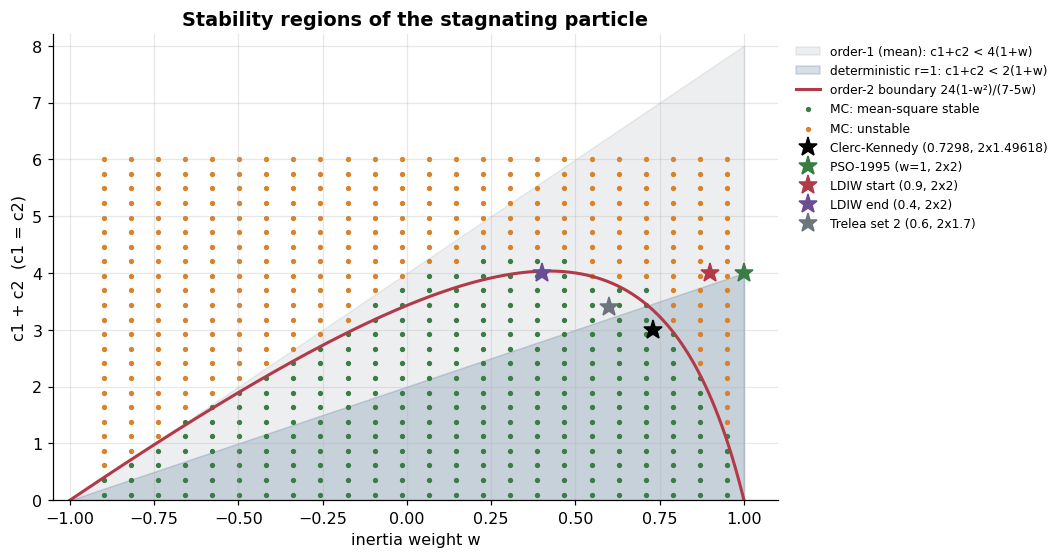

setting                               det r=1  order-1  order-2  rho(M)
Clerc-Kennedy (0.7298, 2x1.49618)        True     True     True  0.9442
PSO-1995 (w=1, 2x2)                     False    False    False  1.3874
LDIW start (0.9, 2x2)                   False     True    False  1.2943
LDIW end (0.4, 2x2)                     False     True     True  0.9812
Trelea set 2 (0.6, 2x1.7)               False     True     True  0.8887
[PASS] default parameters lie inside the deterministic, order-1 and order-2 regions


In [7]:
settings = {
    "Clerc-Kennedy (0.7298, 2x1.49618)": (0.7298, 2 * 1.49618),
    "PSO-1995 (w=1, 2x2)": (1.0, 4.0),
    "LDIW start (0.9, 2x2)": (0.9, 4.0),
    "LDIW end (0.4, 2x2)": (0.4, 4.0),
    "Trelea set 2 (0.6, 2x1.7)": (0.6, 3.4),
}
fig, ax = plt.subplots(figsize=(8.5, 5.5))
wl = np.linspace(-1, 1, 400)
ax.fill_between(wl, 0, 4 * (1 + wl), color=PALETTE["grey"], alpha=0.12, label="order-1 (mean): c1+c2 < 4(1+w)")
ax.fill_between(wl, 0, 2 * (1 + wl), color=PALETTE["blue"], alpha=0.18, label="deterministic r=1: c1+c2 < 2(1+w)")
ax.plot(wl, poli_bound(wl), color=PALETTE["red"], lw=2, label="order-2 boundary 24(1-w²)/(7-5w)")
ax.scatter(WG.ravel()[mc_stable], CG.ravel()[mc_stable], s=6, color=PALETTE["green"], label="MC: mean-square stable")
ax.scatter(WG.ravel()[~mc_stable], CG.ravel()[~mc_stable], s=6, color=PALETTE["orange"], label="MC: unstable")
for k, (name, (w, c)) in enumerate(settings.items()):
    ax.plot(w, c, marker="*", ms=13, color="k" if k == 0 else list(PALETTE.values())[k + 1], ls="none", label=name)
ax.set_xlim(-1.05, 1.1); ax.set_ylim(0, 8.2)
ax.set_xlabel("inertia weight w"); ax.set_ylabel("c1 + c2  (c1 = c2)")
ax.set_title("Stability regions of the stagnating particle"); ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
savefig("w5_pso_stability_regions.png"); plt.show()

print(f"{'setting':36s} {'det r=1':>8s} {'order-1':>8s} {'order-2':>8s}  rho(M)")
for name, (w, c) in settings.items():
    det_ok, o1_ok, o2_ok = abs(w) < 1 and 0 < c < 2 * (1 + w), abs(w) < 1 and 0 < c < 4 * (1 + w), rho2(w, c / 2, c / 2) < 1
    print(f"{name:36s} {str(det_ok):>8s} {str(o1_ok):>8s} {str(o2_ok):>8s}  {rho2(w, c / 2, c / 2):.4f}")
w_d, c_d = settings["Clerc-Kennedy (0.7298, 2x1.49618)"]
check_true(abs(w_d) < 1 and c_d < 2 * (1 + w_d) and c_d < 4 * (1 + w_d) and c_d < poli_bound(w_d),
           "default parameters lie inside the deterministic, order-1 and order-2 regions")

The default point sits inside all three regions, but close to the order-2 boundary ($\rho(M)\approx0.944$):
the mean-square contraction per iteration is slow, which is exactly what gives PSO time to explore.
PSO-1995 ($w=1$) is outside every region (marginal in the mean, unstable in mean square), and the classic linearly
decreasing inertia weight starts *outside* the order-2 region ($w=0.9$) and ends inside ($w=0.4$): it is a schedule
from divergent exploration to convergent exploitation.

## 4. Swarm explosion

A full swarm is not stagnating, but an exploding swarm quickly stops improving its memories, so the stagnation model
applies. We run gbest PSO on the 10-D sphere **without any boundary handling**, 20 seeds, and track the swarm radius
$\mathrm{rad}_t=\frac1n\sum_i\Vert x_i-\bar x\Vert$ for PSO-1995 without and with $v_{\max}$, and for constriction.

In [8]:
def pso_diag(f, d, lo, hi, iters, runs, n=40, w=0.7298, c1=1.49618, c2=1.49618, topology="gbest", vmax=None, rng=None):
    """Minimal vectorised PSO (no bound handling) that records swarm diversity and best-so-far per iteration."""
    X = rng.uniform(lo, hi, (runs, n, d)); V = (rng.uniform(lo, hi, (runs, n, d)) - X) / 2
    Pf = f(X.reshape(-1, d)).reshape(runs, n); P = X.copy()
    ar, idx = np.arange(runs)[:, None], np.arange(n)
    nbr = np.stack([(idx - 1) % n, idx, (idx + 1) % n], 1) if topology == "ring" else None
    rad, best = [], []
    for t in range(iters):
        gi = (np.broadcast_to(Pf.argmin(1)[:, None], (runs, n)) if nbr is None
              else nbr[idx, Pf[:, nbr].argmin(2)])
        L = P[ar, gi]
        r = rng.random((2, runs, n, d))
        V = w * V + c1 * r[0] * (P - X) + c2 * r[1] * (L - X)
        if vmax is not None:
            V = np.clip(V, -vmax * (hi - lo), vmax * (hi - lo))
        X = X + V
        F = f(X.reshape(-1, d)).reshape(runs, n)
        imp = F < Pf; P[imp], Pf[imp] = X[imp], F[imp]
        rad.append(np.linalg.norm(X - X.mean(1, keepdims=True), axis=2).mean(1))
        best.append(Pf.min(1))
    return np.array(rad).T, np.array(best).T

sph = BENCHMARKS["sphere"].f
explo = {
    "PSO-1995, no vmax": dict(w=1.0, c1=2.0, c2=2.0),
    "PSO-1995, vmax=0.2": dict(w=1.0, c1=2.0, c2=2.0, vmax=0.2),
    "constriction": dict(),
}
ex_res = {k: pso_diag(sph, 10, -5.12, 5.12, 300, 20, rng=np.random.default_rng(10 + i), **kw)
          for i, (k, kw) in enumerate(explo.items())}
for k, (rad, best) in ex_res.items():
    print(f"{k:20s} median radius: t=1 {np.median(rad[:, 0]):.2e}, t=300 {np.median(rad[:, -1]):.2e};"
          f"  median best f {np.median(best[:, -1]):.2e}")
check_true(np.median(ex_res["PSO-1995, no vmax"][0][:, -1]) > 1e6 * np.median(ex_res["PSO-1995, no vmax"][0][:, 0]),
           "w=1, c1=c2=2 without clamping: swarm radius grows by more than 10^6 in 300 iterations")
check_true(np.median(ex_res["constriction"][0][:, -1]) < 1e-6 * np.median(ex_res["constriction"][0][:, 0]),
           "constriction: swarm radius shrinks by more than 10^6 in 300 iterations")

PSO-1995, no vmax    median radius: t=1 8.77e+00, t=300 1.69e+15;  median best f 1.91e+01
PSO-1995, vmax=0.2   median radius: t=1 5.35e+00, t=300 3.58e+00;  median best f 1.03e+00
constriction         median radius: t=1 5.78e+00, t=300 7.76e-07;  median best f 6.99e-15
[PASS] w=1, c1=c2=2 without clamping: swarm radius grows by more than 10^6 in 300 iterations
[PASS] constriction: swarm radius shrinks by more than 10^6 in 300 iterations


**Growth rate.** In mean square the stagnating particle grows by $\rho(M)$ per iteration, i.e. the root-mean-square
radius by $\sqrt{\rho(M)}$. The *typical* (median) trajectory of a heavy-tailed product grows more slowly (its rate is the
top Lyapunov exponent, which is at most $\tfrac12\log\rho(M)$ by Jensen's inequality). We compare the fitted median
log-radius slope of the exploding swarm with $\tfrac12\log\rho(M(1,2,2))$, and print the Lyapunov rate of a single
stagnating coordinate for reference. The swarm radius averages the distances of 40 heavy-tailed particles, so its
growth rate should lie between the two (the average is dominated by the largest particles). For a full swarm neither
number is a theorem (the attractors still move a little); we check the stagnation upper bound, which Jensen's
inequality makes an upper bound for any typical statistic.

fitted growth rate of the median radius: 0.1019 per iteration; mean-square rate 0.5*log rho(M) = 0.1637; typical (Lyapunov) rate of one stagnating coordinate = 0.0760
[PASS] observed explosion rate is positive and below the mean-square bound


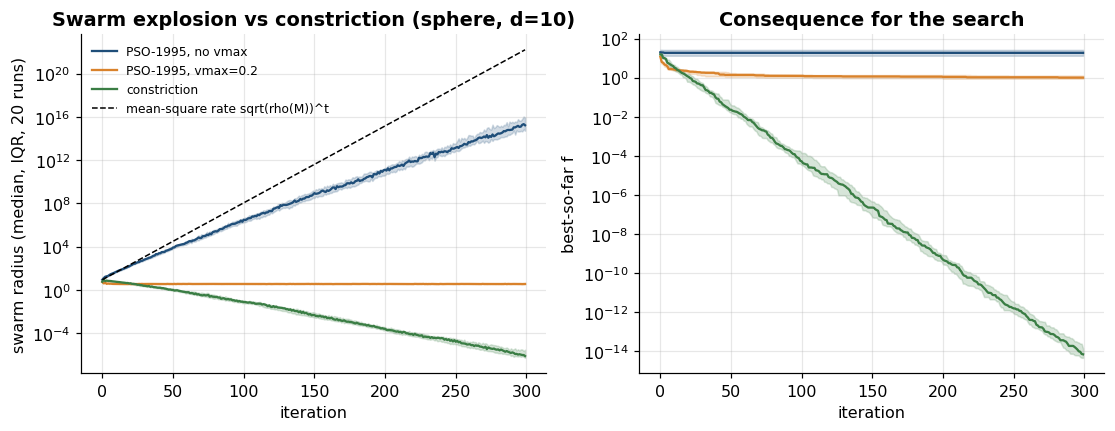

In [9]:
rad_x = ex_res["PSO-1995, no vmax"][0]
slope = np.polyfit(np.arange(100, 300), np.log(np.median(rad_x[:, 100:], axis=0)), 1)[0]
bound = 0.5 * np.log(rho2(1.0, 2.0, 2.0))
ly_x = simulate_particles(1.0, 2.0, 2.0, 20000, 120, np.random.default_rng(6), y0=np.random.default_rng(7).standard_normal(20000))
gamma_x = np.polyfit(np.arange(40, 120), np.log(np.abs(ly_x[40:])).mean(1), 1)[0]
print(f"fitted growth rate of the median radius: {slope:.4f} per iteration; mean-square rate 0.5*log rho(M) = {bound:.4f}; "
      f"typical (Lyapunov) rate of one stagnating coordinate = {gamma_x:.4f}")
check_true(0 < slope <= bound, "observed explosion rate is positive and below the mean-square bound")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, (name, (rad, best)) in enumerate(ex_res.items()):
    q1, m, q3 = np.percentile(rad, [25, 50, 75], axis=0)
    axes[0].plot(m, label=name, color=list(PALETTE.values())[k]); axes[0].fill_between(np.arange(300), q1, q3, alpha=0.2, color=list(PALETTE.values())[k])
    q1, m, q3 = np.percentile(np.maximum(best, 1e-300), [25, 50, 75], axis=0)
    axes[1].plot(m, label=name, color=list(PALETTE.values())[k]); axes[1].fill_between(np.arange(300), q1, q3, alpha=0.2, color=list(PALETTE.values())[k])
t_ = np.arange(300)
axes[0].plot(t_, np.median(rad_x[:, 0]) * np.exp(bound * t_), "k--", lw=1, label="mean-square rate sqrt(rho(M))^t")
for ax, yl in zip(axes, ["swarm radius (median, IQR, 20 runs)", "best-so-far f"]):
    ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel(yl)
axes[0].set_title("Swarm explosion vs constriction (sphere, d=10)"); axes[0].legend(fontsize=8)
axes[1].set_title("Consequence for the search")
savefig("w5_pso_explosion.png"); plt.show()

## 5. Diversity decay in working swarms

Diversity (swarm radius) is the practical face of the stability analysis. With the default parameters we measure the
log-linear decay rate of the radius for gbest and ring topologies on the sphere (unimodal) and Rastrigin (multimodal),
$d=10$, 20 runs each, and compare with two stagnation predictions: the root-mean-square factor $\sqrt{\rho(M)}$ and
the *typical* factor $e^{\gamma}$, where $\gamma=\lim_t\frac1t\mathbb E\log|y_t|$ is the top Lyapunov exponent
(estimated by simulation). Jensen's inequality gives $2\gamma\le\log\rho(M)$, so typical trajectories contract
at least as fast as the RMS.

stagnation predictions per iteration: RMS factor sqrt(rho(M)) = 0.9717, typical (Lyapunov) factor = 0.9074
[PASS] Jensen: typical contraction factor <= RMS contraction factor
  sphere    gbest : fitted radius contraction factor per iteration 0.9440;  median final radius 2.3e-09, median best f 3.5e-20
  sphere    ring  : fitted radius contraction factor per iteration 0.9693;  median final radius 4.5e-05, median best f 1.5e-10
  rastrigin gbest : fitted radius contraction factor per iteration 0.9911;  median final radius 1.1e-01, median best f 6.0e+00
  rastrigin ring  : fitted radius contraction factor per iteration 0.9991;  median final radius 3.8e+00, median best f 6.0e+00


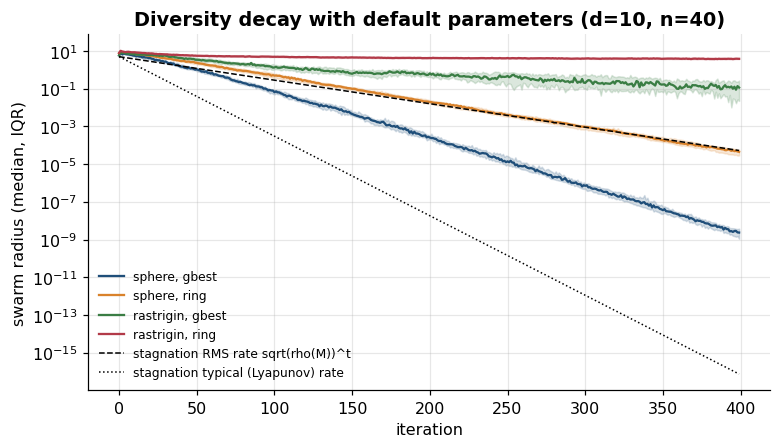

In [10]:
div = {}
for fname in ["sphere", "rastrigin"]:
    bm = BENCHMARKS[fname]
    for k, topo in enumerate(["gbest", "ring"]):
        div[fname, topo] = pso_diag(bm.f, 10, bm.lower, bm.upper, 400, 20, topology=topo, rng=np.random.default_rng(30 + k))
pred = np.sqrt(rho2(0.7298, 1.49618, 1.49618))
ly = simulate_particles(0.7298, 1.49618, 1.49618, 20000, 400, np.random.default_rng(4), y0=np.random.default_rng(5).standard_normal(20000))
lyap = np.exp(np.polyfit(np.arange(50, 400), np.log(np.abs(ly[50:])).mean(1), 1)[0])
print(f"stagnation predictions per iteration: RMS factor sqrt(rho(M)) = {pred:.4f}, typical (Lyapunov) factor = {lyap:.4f}")
check_true(lyap <= pred, "Jensen: typical contraction factor <= RMS contraction factor")
for (fname, topo), (rad, best) in div.items():
    med = np.median(rad, axis=0)
    rate = np.exp(np.polyfit(np.arange(50, 400), np.log(med[50:]), 1)[0])
    print(f"  {fname:9s} {topo:6s}: fitted radius contraction factor per iteration {rate:.4f};"
          f"  median final radius {med[-1]:.1e}, median best f {np.median(best[:, -1]):.1e}")

fig, ax = plt.subplots(figsize=(8, 4.2))
for k, ((fname, topo), (rad, _)) in enumerate(div.items()):
    q1, m, q3 = np.percentile(rad, [25, 50, 75], axis=0)
    ax.plot(m, label=f"{fname}, {topo}", color=list(PALETTE.values())[k])
    ax.fill_between(np.arange(400), q1, q3, alpha=0.18, color=list(PALETTE.values())[k])
ax.plot(np.arange(400), 5 * pred ** np.arange(400), "k--", lw=1, label="stagnation RMS rate sqrt(rho(M))^t")
ax.plot(np.arange(400), 5 * lyap ** np.arange(400), "k:", lw=1, label="stagnation typical (Lyapunov) rate")
ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("swarm radius (median, IQR)")
ax.set_title("Diversity decay with default parameters (d=10, n=40)"); ax.legend(fontsize=8)
savefig("w5_pso_diversity.png"); plt.show()

**Interpretation.** On the sphere the gbest swarm contracts at a rate between the two stagnation predictions:
faster than the RMS factor (the median is a typical, not a mean-square, statistic) but slower than the typical
stagnating particle, because every improvement moves the attractors and re-injects spread. The ring contracts more
slowly than gbest, since its particles follow different attractors. On Rastrigin both topologies contract much more
slowly: particles sit in different basins, so $p_i\neq l_i$ and the stagnation variance tends to a positive limit
$\propto(p-l)^2$ instead of zero; once all attractors fall into one basin, diversity collapses — premature
convergence. The stability analysis explains the *regime* (contracting vs exploding, and roughly how fast), and gives
a principled reason for the default parameters; it is not a runtime prediction.

*AI relevance.* The same second-moment reasoning is used to analyse momentum SGD ($x_{t+1}=x_t-\eta g_t+\beta(x_t-x_{t-1})$
has exactly the characteristic polynomial above with $w=\beta$, $\varphi=\eta\lambda_{\text{Hessian}}$) — the
heavy-ball stability region $0<\eta\lambda<2(1+\beta)$ is the deterministic PSO region.

## Key takeaways

- Under stagnation a PSO coordinate is a linear second-order recurrence with random coefficient
  $\varphi_t=c_1r_1+c_2r_2$; its fixed point is a random convex combination of $p$ and $l$.
- Deterministic region $|w|<1$, $0<\varphi<2(1+w)$ (Jury conditions); with $\varphi=c_1+c_2$ it is the conservative
  $r\equiv1$ region, with $\varphi=(c_1+c_2)/2$ it is order-1 (mean) stability.
- Mean-square stability is the spectral radius of a $3\times3$ moment matrix; its boundary is Poli's
  $c_1+c_2=24(1-w^2)/(7-5w)$ — verified here to $10^{-8}$ by bisection and statistically by simulation.
- Heavy tails make naive Monte Carlo estimates of second moments optimistic; exact moment recursions are the
  reliable tool.
- $w=1$ explodes without $v_{\max}$; the defaults $(0.7298, 1.49618)$ are inside every region but close to the
  order-2 boundary ($\rho(M)\approx0.944$), which balances contraction against exploration.

## Exercises

1. ★ Show that the deterministic region is a triangle in the $(w,\varphi)$ plane and identify where the roots are
   complex (oscillatory convergence) versus real (monotone or zig-zag convergence).
2. ★ Derive $\mathbb E[a^2]$ for general $c_1\neq c_2$ and plot the order-2 region for $c_2=2c_1$.
3. ★★ With $p\neq l$ the recurrence has a forcing term. Derive the stationary mean $\frac{c_1p+c_2l}{c_1+c_2}$ and the
   stationary variance of $x_t$, and check it by simulation.
4. ★★ Prove that the characteristic polynomial of momentum gradient descent on a quadratic coincides with the
   deterministic PSO model and translate the stability region into a learning-rate bound $\eta<2(1+\beta)/L$.
5. ★★ Estimate the top Lyapunov exponent of the random recurrence by averaging $\log|y_t|$ over long runs and plot
   the region where it is negative (almost-sure stability) next to the order-2 region. Which is larger, and why?
6. ★★★ Poli's analysis ignores the change of $p$ and $l$. Design an experiment on the sphere that measures how
   often improvements occur as a function of $\rho(M)$ and relate the observed radius contraction rate to the
   stagnation prediction.